# Pre trained network
![imagen](./img/llustrations-of-transfer-learning-a-neural-network-is-pretrained-on-ImageNet-and.png)

Estas son las arquitecturas de redes neuronales más utilizadas en la comunidad. Para más detalle sobre el funcionamiento de cada red, consultar el [Hands on Machine Learning for Python](https://learning.oreilly.com/library/view/hands-on-machine-learning/9781492032632/ch14.html#cnn_chapter).
* VGG-16
* VGG-19
* Inception V3
* XCeption
* ResNet-50

Las redes se pueden incorporar entrenadas, o sin entrenar.

## ResNet50V2

In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing import image
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import numpy as np
from skimage.io import imread
import cv2

from tensorflow.keras.applications.resnet_v2 import ResNet50V2, decode_predictions, preprocess_input

In [2]:
# CODE MODEL
base_model = ResNet50V2(include_top= True, input_shape=(224, 224, 3), weights='imagenet', classifier_activation= 'softmax')



102869336/102869336 [==============================] - 4s 0us/step


In [3]:
len(base_model.layers)

192

In [4]:
base_model.summary()

Model: "resnet50v2"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 224, 224, 3)]        0         []                            
                                                                                                  
 conv1_pad (ZeroPadding2D)   (None, 230, 230, 3)          0         ['input_1[0][0]']             
                                                                                                  
 conv1_conv (Conv2D)         (None, 112, 112, 64)         9472      ['conv1_pad[0][0]']           
                                                                                                  
 pool1_pad (ZeroPadding2D)   (None, 114, 114, 64)         0         ['conv1_conv[0][0]']          
                                                                                         

                                                                                                  
 conv2_block1_2_relu (Activ  (None, 56, 56, 64)           0         ['conv2_block1_2_bn[0][0]']   
 ation)                                                                                           
                                                                                                  
 conv2_block1_0_conv (Conv2  (None, 56, 56, 256)          16640     ['conv2_block1_preact_relu[0][
 D)                                                                 0]']                          
                                                                                                  
 conv2_block1_3_conv (Conv2  (None, 56, 56, 256)          16640     ['conv2_block1_2_relu[0][0]'] 
 D)                                                                                               
                                                                                                  
 conv2_blo

Cargamos algunas imagenes desde local, para ver qué tal funciona la red ResNet50V2 ya entrenada.

In [5]:
# CODE READ DATA

import os

def read_data(path):
    X = []
    for file in os.listdir(path):
        image = imread(path + '/' + file)
        smallimage = cv2.resize(image, (224,224))
        print(path + '/' + file)

        X.append(smallimage)
    return np.array(X)


In [6]:
X_test = read_data('img')

#Preprocesar las imagenes tal y como entran en el model
X_test = preprocess_input(X_test)
print(X_test.shape)

img/bear-1.jpg
img/cat.8016.jpg
img/cat.8037.jpg
img/dog.11856.jpg
img/dog.11857.jpg
img/horse.jpg
img/karate.jpg
img/llustrations-of-transfer-learning-a-neural-network-is-pretrained-on-ImageNet-and.png
img/pizza.jpg
(9, 224, 224, 3)


In [7]:
# CODE preds

preds = base_model.predict(X_test)

1/1 [==============================] - 2s 2s/step


In [8]:
len(preds)

9

In [9]:
preds

array([[2.6120958e-10, 5.8382682e-10, 4.8970450e-10, ..., 2.4313812e-10,
        3.7808964e-10, 1.9815998e-09],
       [1.9770730e-05, 5.4083095e-05, 1.6641226e-05, ..., 1.1837185e-05,
        1.1198787e-04, 2.5801474e-04],
       [8.5168047e-08, 1.4822004e-07, 2.9617496e-08, ..., 6.2941929e-08,
        3.8534401e-07, 2.3654377e-06],
       ...,
       [1.0001746e-07, 7.6349097e-05, 2.6081028e-05, ..., 2.8111290e-06,
        5.1168959e-06, 9.2755263e-06],
       [1.3035239e-05, 5.3366266e-06, 6.3939362e-05, ..., 1.6010317e-05,
        6.9855896e-06, 1.3746723e-04],
       [4.6689227e-08, 3.3564794e-07, 8.2979241e-08, ..., 4.4028670e-07,
        4.2722223e-07, 1.8702542e-08]], dtype=float32)

In [10]:
len(preds[0])

1000

In [11]:
decodes = decode_predictions(preds, top=3)

35363/35363 [==============================] - 0s 0us/step


In [12]:
decodes

[[('n02132136', 'brown_bear', 0.9994438),
  ('n02112137', 'chow', 0.0005415575),
  ('n02133161', 'American_black_bear', 8.780994e-06)],
 [('n02124075', 'Egyptian_cat', 0.64985),
  ('n02123597', 'Siamese_cat', 0.1678735),
  ('n02123159', 'tiger_cat', 0.06044939)],
 [('n02124075', 'Egyptian_cat', 0.82098454),
  ('n02127052', 'lynx', 0.1267942),
  ('n02123597', 'Siamese_cat', 0.021530634)],
 [('n02106550', 'Rottweiler', 0.73291016),
  ('n02112706', 'Brabancon_griffon', 0.08508464),
  ('n02093256', 'Staffordshire_bullterrier', 0.031059291)],
 [('n02106030', 'collie', 0.99525696),
  ('n02105855', 'Shetland_sheepdog', 0.004742948),
  ('n12057211', "yellow_lady's_slipper", 9.142557e-09)],
 [('n02113799', 'standard_poodle', 0.32455716),
  ('n02091831', 'Saluki', 0.300353),
  ('n02412080', 'ram', 0.123279676)],
 [('n09835506', 'ballplayer', 0.54023373),
  ('n02799071', 'baseball', 0.24657959),
  ('n02777292', 'balance_beam', 0.117252305)],
 [('n06359193', 'web_site', 0.8231874),
  ('n03857828',

In [13]:
# CODE decode preds
for j in decodes:
    print('####################')
    for i,decode in enumerate(j):
        print("Predicted:\n", decode[1], decode[2])

####################
Predicted:
 brown_bear 0.9994438
Predicted:
 chow 0.0005415575
Predicted:
 American_black_bear 8.780994e-06
####################
Predicted:
 Egyptian_cat 0.64985
Predicted:
 Siamese_cat 0.1678735
Predicted:
 tiger_cat 0.06044939
####################
Predicted:
 Egyptian_cat 0.82098454
Predicted:
 lynx 0.1267942
Predicted:
 Siamese_cat 0.021530634
####################
Predicted:
 Rottweiler 0.73291016
Predicted:
 Brabancon_griffon 0.08508464
Predicted:
 Staffordshire_bullterrier 0.031059291
####################
Predicted:
 collie 0.99525696
Predicted:
 Shetland_sheepdog 0.004742948
Predicted:
 yellow_lady's_slipper 9.142557e-09
####################
Predicted:
 standard_poodle 0.32455716
Predicted:
 Saluki 0.300353
Predicted:
 ram 0.123279676
####################
Predicted:
 ballplayer 0.54023373
Predicted:
 baseball 0.24657959
Predicted:
 balance_beam 0.117252305
####################
Predicted:
 web_site 0.8231874
Predicted:
 oscilloscope 0.05327221
Predicted:
 swit

## VGG16
En este caso vamos a importar la red VGG16, que utilizaremos como red preentrenada y completaremos con una fully connected layer. 

In [15]:
import pandas as pd
from sklearn.model_selection import train_test_split

IM_SIZE=32

TRAIN_PATH = 'C:/Users/urkow/Documents/Documentos_Clase/zz_conv_img/teoria/train/'
filenames = os.listdir(TRAIN_PATH)
categories = []
for filename in filenames:
    category = filename.split('.')[0]
    categories.append(category)
    
df = pd.DataFrame({
    'filenames': filenames,
    'category': categories
})

train_df, validate_df = train_test_split(df,
                                         test_size=0.20,
                                         random_state=42)

train_df = train_df.reset_index(drop=True)
validate_df = validate_df.reset_index(drop=True)

In [16]:
train_df.head()

,filenames,category
0,cat.3337.jpg,cat
1,dog.12039.jpg,dog
2,cat.2542.jpg,cat
3,dog.10283.jpg,dog
4,dog.10384.jpg,dog


In [17]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator


# Add our data-augmentation parameters to ImageDataGenerator
train_datagen = ImageDataGenerator(rescale = 1./255.,
                                   rotation_range = 40,
                                   width_shift_range = 0.2,
                                   height_shift_range = 0.2,
                                   shear_range = 0.2,
                                   zoom_range = 0.2,
                                   horizontal_flip = True)

# Note that the validation data should not be augmented!
validation_datagen = ImageDataGenerator(rescale = 1.0/255. )

In [18]:
# Flow training images in batches of 20 using train_datagen generator
train_generator = train_datagen.flow_from_dataframe(train_df,
                                                    TRAIN_PATH,
                                                    x_col='filenames',
                                                    y_col='category',
                                                    batch_size = 20,
                                                    class_mode = 'binary',
                                                    target_size = (32, 32))

# Flow validation images in batches of 20 using test_datagen generator
validation_generator = validation_datagen.flow_from_dataframe(validate_df,
                                                              TRAIN_PATH,
                                                              x_col='filenames',
                                                              y_col='category',
                                                              batch_size = 20,
                                                              class_mode = 'binary',
                                                              target_size = (IM_SIZE, IM_SIZE))

Found 5260 validated image filenames belonging to 2 classes.
Found 1316 validated image filenames belonging to 2 classes.


In [19]:
from tensorflow.keras.applications.vgg16 import VGG16

# CODE model
base_model = VGG16(input_shape=(IM_SIZE,IM_SIZE,3),
                    include_top=False,
                    weights = 'imagenet'
                )

In [20]:
len(base_model.layers)

19

In [21]:
base_model.summary()

Model: "vgg16"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 32, 32, 3)]       0         
                                                                 
 block1_conv1 (Conv2D)       (None, 32, 32, 64)        1792      
                                                                 
 block1_conv2 (Conv2D)       (None, 32, 32, 64)        36928     
                                                                 
 block1_pool (MaxPooling2D)  (None, 16, 16, 64)        0         
                                                                 
 block2_conv1 (Conv2D)       (None, 16, 16, 128)       73856     
                                                                 
 block2_conv2 (Conv2D)       (None, 16, 16, 128)       147584    
                                                                 
 block2_pool (MaxPooling2D)  (None, 8, 8, 128)         0     

In [22]:

##### FULLY CONNECTED LAYER #####
# Flatten the output layer to 1 dimension
x = layers.Flatten()(base_model.output)

# Add a fully connected layer with 512 hidden units and ReLU activation
x = layers.Dense(512, activation='relu')(x)

# Add a dropout rate of 0.25
x = layers.Dropout(0.25)(x)

# Add a final sigmoid layer for classification
x = layers.Dense(1, activation='sigmoid')(x)

model = tf.keras.models.Model(base_model.input, x)
    
model.compile(optimizer = 'adam', loss = 'binary_crossentropy',metrics = ['acc'])

In [23]:
len(model.layers)

23

In [24]:
model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 32, 32, 3)]       0         
                                                                 
 block1_conv1 (Conv2D)       (None, 32, 32, 64)        1792      
                                                                 
 block1_conv2 (Conv2D)       (None, 32, 32, 64)        36928     
                                                                 
 block1_pool (MaxPooling2D)  (None, 16, 16, 64)        0         
                                                                 
 block2_conv1 (Conv2D)       (None, 16, 16, 128)       73856     
                                                                 
 block2_conv2 (Conv2D)       (None, 16, 16, 128)       147584    
                                                                 
 block2_pool (MaxPooling2D)  (None, 8, 8, 128)         0     

In [25]:
vgghist = model.fit(train_generator,
                   validation_data = validation_generator,
                   batch_size = 128,
                   epochs = 5)

Epoch 1/5


263/263 [==============================] - 51s 179ms/step - loss: 0.7035 - acc: 0.5819 - val_loss: 0.6658 - val_acc: 0.6185
Epoch 2/5
263/263 [==============================] - 48s 182ms/step - loss: 0.6833 - acc: 0.5996 - val_loss: 0.6656 - val_acc: 0.6185
Epoch 3/5
263/263 [==============================] - 46s 175ms/step - loss: 0.6738 - acc: 0.6074 - val_loss: 0.6690 - val_acc: 0.6185
Epoch 4/5
263/263 [==============================] - 46s 175ms/step - loss: 0.6708 - acc: 0.6103 - val_loss: 0.6663 - val_acc: 0.6185
Epoch 5/5
263/263 [==============================] - 46s 176ms/step - loss: 0.6707 - acc: 0.6099 - val_loss: 0.6648 - val_acc: 0.6185


<Axes: >

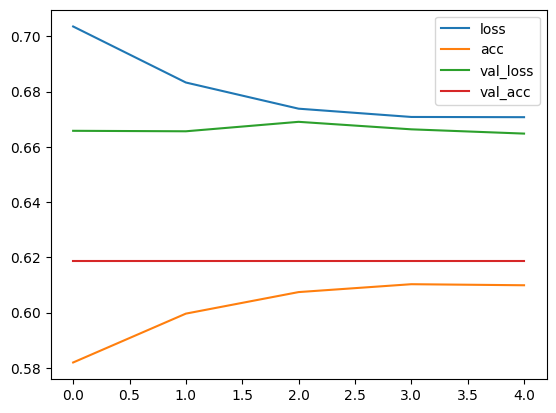

In [26]:
pd.DataFrame(vgghist.history).plot()

## ResNet50V2 sin últimas capas y sin pesos preentrenados

In [27]:
IM_SIZE=32

base_model = ResNet50V2(input_shape = (32, 32, 3),
                       include_top = None,
                       weights = None,
                       classifier_activation= "softmax")


train_generator = train_datagen.flow_from_dataframe(train_df,
                                                    TRAIN_PATH,
                                                    x_col='filenames',
                                                    y_col='category',
                                                    batch_size = 20,
                                                    class_mode = 'binary',
                                                    target_size = (32, 32))

# Flow validation images in batches of 20 using test_datagen generator
validation_generator = validation_datagen.flow_from_dataframe(validate_df,
                                                              TRAIN_PATH,
                                                              x_col='filenames',
                                                              y_col='category',
                                                              batch_size = 20,
                                                              class_mode = 'binary',
                                                              target_size = (32, 32))

Found 5260 validated image filenames belonging to 2 classes.
Found 1316 validated image filenames belonging to 2 classes.


In [28]:
len(base_model.layers)

190

In [29]:
base_model.summary()

Model: "resnet50v2"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_3 (InputLayer)        [(None, 32, 32, 3)]          0         []                            
                                                                                                  
 conv1_pad (ZeroPadding2D)   (None, 38, 38, 3)            0         ['input_3[0][0]']             
                                                                                                  
 conv1_conv (Conv2D)         (None, 16, 16, 64)           9472      ['conv1_pad[0][0]']           
                                                                                                  
 pool1_pad (ZeroPadding2D)   (None, 18, 18, 64)           0         ['conv1_conv[0][0]']          
                                                                                         

In [30]:
x = layers.Flatten()(base_model.output)

# Add a fully connected layer with 512 hidden units and ReLU activation
x = layers.Dense(512, activation='relu')(x)

# Add a dropout rate of 0.5
x = layers.Dropout(0.1)(x)

# Add a final sigmoid layer for classification
x = layers.Dense(1, activation='sigmoid')(x)

model = tf.keras.models.Model(base_model.input, x)
    
model.compile(optimizer = 'adam', loss = 'binary_crossentropy',metrics = ['acc'])

In [31]:
len(model.layers)

194

In [32]:
model.fit(train_generator,
         validation_data = validation_generator,
         steps_per_epoch = 100,
         epochs = 20)

Epoch 1/20
100/100 [==============================] - 44s 268ms/step - loss: 0.7821 - acc: 0.5705 - val_loss: 0.6786 - val_acc: 0.6185
Epoch 2/20
100/100 [==============================] - 26s 258ms/step - loss: 0.6943 - acc: 0.6020 - val_loss: 0.6621 - val_acc: 0.6185
Epoch 3/20
100/100 [==============================] - 26s 262ms/step - loss: 0.6758 - acc: 0.6130 - val_loss: 0.6581 - val_acc: 0.6193
Epoch 4/20
100/100 [==============================] - 27s 266ms/step - loss: 0.6537 - acc: 0.6305 - val_loss: 0.6664 - val_acc: 0.6292
Epoch 5/20
100/100 [==============================] - 26s 263ms/step - loss: 0.6465 - acc: 0.6405 - val_loss: 0.6260 - val_acc: 0.6695
Epoch 6/20
100/100 [==============================] - 26s 262ms/step - loss: 0.6457 - acc: 0.6275 - val_loss: 0.6197 - val_acc: 0.6733
Epoch 7/20
100/100 [==============================] - 26s 264ms/step - loss: 0.6276 - acc: 0.6550 - val_loss: 0.6816 - val_acc: 0.5638
Epoch 8/20
100/100 [==============================] - 2

In [33]:
test_datagen = ImageDataGenerator(rescale=1./255)  # Escala los píxeles entre 0 y 1

In [34]:
# # Flow validation images in batches of 20 using test_datagen generator
# test_generator = test_datagen.flow_from_dataframe(test_df,
#                                                              TRAIN_PATH,
#                                                              x_col='filenames',
#                                                              y_col='category',
#                                                              batch_size = 20,
#                                                              class_mode = 'binary',
#                                                              target_size = (224, 224))

In [35]:
# loss, accuracy = model.evaluate(validation_generator, verbose=1)